## Before mandate - Face mask

## After mandate - Face mask

## Before mandate - Protective behaviour

## After mandate - Protective behaviour

## Full comparison table

...

,task,label,model,roc_auc,f1,precision,recall,accuracy,best_cv_auc
0,after_mask,After mandate - Face mask,xgboost,0.8923,0.8951,0.8911,0.8992,0.8512,0.8926
1,after_protective,After mandate - Protective behaviour,xgboost,0.8493,0.8485,0.8748,0.8237,0.7871,0.8516
2,before_mask,Before mandate - Face mask,xgboost,0.8461,0.6141,0.5625,0.6762,0.7805,0.8606
3,before_protective,Before mandate - Protective behaviour,random_forest,0.7963,0.7404,0.7260,0.7554,0.7196,0.7791


## AUC pivot

task,after_mask,after_protective,before_mask,before_protective
model,,,,
classification_tree,0.8546,0.8000,0.8005,0.7435
logistic_regression,0.8302,0.7736,0.8151,0.7292
random_forest,0.8895,0.8415,0.8407,0.7963
xgboost,0.8923,0.8493,0.8461,0.7920


## F1 pivot

task,after_mask,after_protective,before_mask,before_protective
model,,,,
classification_tree,0.8726,0.8048,0.5794,0.6970
logistic_regression,0.8203,0.7907,0.5804,0.6855
random_forest,0.8950,0.8542,0.6078,0.7404
xgboost,0.8951,0.8485,0.6141,0.7311


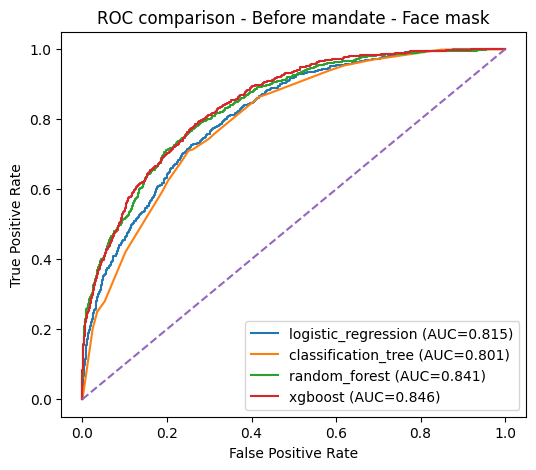

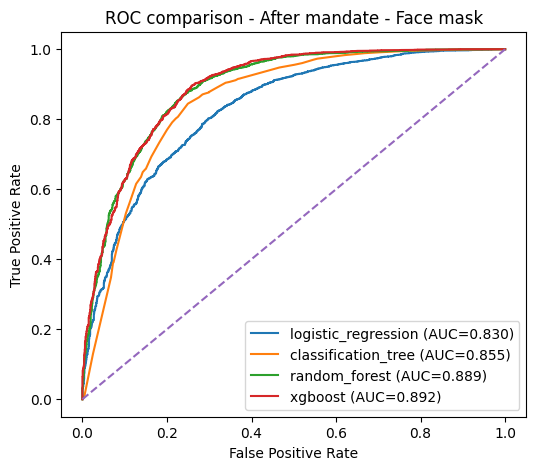

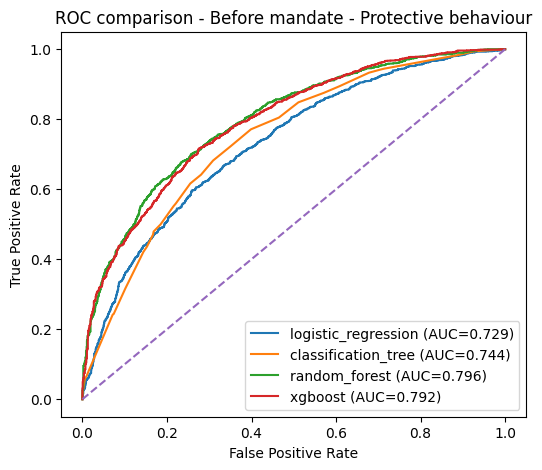

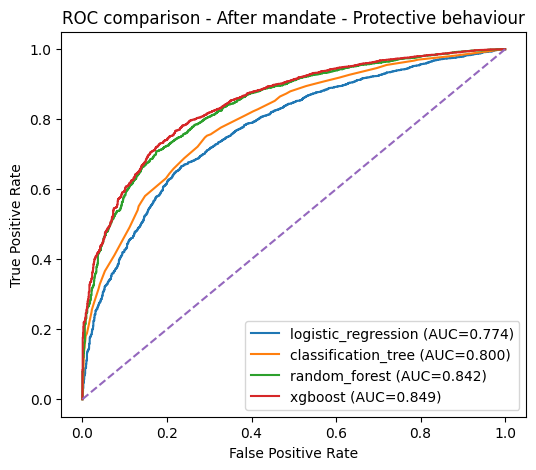

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score,
    f1_score,
    roc_curve,
)

DATA_DIR = Path("../data/paper_final_splits")

RANDOM_STATE = 1948883
N_SPLITS = 5
N_ITER_TREE = 40
N_ITER_RF = 40
N_ITER_XGB = 40

TASKS = {
    "before_mask": "Before mandate - Face mask",
    "after_mask": "After mandate - Face mask",
    "before_protective": "Before mandate - Protective behaviour",
    "after_protective": "After mandate - Protective behaviour",
}

METRICS = ["precision", "recall", "roc_auc", "accuracy", "f1"]


def load_task(task):
    X_train = pd.read_csv(DATA_DIR / f"X_train_{task}.csv")
    X_test = pd.read_csv(DATA_DIR / f"X_test_{task}.csv")
    y_train = pd.read_csv(DATA_DIR / f"y_train_{task}.csv").iloc[:, 0].astype(int)
    y_test = pd.read_csv(DATA_DIR / f"y_test_{task}.csv").iloc[:, 0].astype(int)
    return X_train, X_test, y_train, y_test


def upsample(X, y, seed):
    ros = RandomOverSampler(random_state=seed)
    X_up, y_up = ros.fit_resample(X, y)
    return X_up, pd.Series(y_up, name="target")


def get_metrics(y_true, y_pred, y_prob):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def run_logistic(X_train, X_test, y_train, y_test):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_rows = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        X_tr_up, y_tr_up = upsample(X_tr, y_tr, RANDOM_STATE + fold)

        model = LogisticRegression(
            max_iter=5000,
            solver="liblinear",
            random_state=RANDOM_STATE
        )
        model.fit(X_tr_up, y_tr_up)

        y_val_pred = model.predict(X_val)
        y_val_prob = model.predict_proba(X_val)[:, 1]

        row = get_metrics(y_val, y_val_pred, y_val_prob)
        row["fold"] = fold
        cv_rows.append(row)

    cv_df = pd.DataFrame(cv_rows)

    X_train_up, y_train_up = upsample(X_train, y_train, RANDOM_STATE)
    final_model = LogisticRegression(
        max_iter=5000,
        solver="liblinear",
        random_state=RANDOM_STATE
    )
    final_model.fit(X_train_up, y_train_up)

    y_test_pred = final_model.predict(X_test)
    y_test_prob = final_model.predict_proba(X_test)[:, 1]

    return {
        "best_params": {},
        "best_cv_auc": cv_df["roc_auc"].mean(),
        "test_metrics": get_metrics(y_test, y_test_pred, y_test_prob),
        "y_test_prob": y_test_prob,
        "y_test": y_test,
    }


def run_tree_search(X_train, X_test, y_train, y_test):
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])

    param_distributions = {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 5, 8, 10, 12, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20, 30, 50],
        "model__min_samples_leaf": [1, 2, 5, 10, 20],
        "model__min_impurity_decrease": [0.0, 0.0001, 0.001, 0.005, 0.01],
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=N_ITER_TREE,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_test_pred = best_model.predict(X_test)
    y_test_prob = best_model.predict_proba(X_test)[:, 1]

    return {
        "best_params": search.best_params_,
        "best_cv_auc": search.best_score_,
        "test_metrics": get_metrics(y_test, y_test_pred, y_test_prob),
        "y_test_prob": y_test_prob,
        "y_test": y_test,
    }


def run_rf_search(X_train, X_test, y_train, y_test):
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(
            n_estimators=250,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    param_distributions = {
        "model__max_depth": [5, 8, 10, 12, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20, 30],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, None],
        "model__bootstrap": [True],
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=N_ITER_RF,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_test_pred = best_model.predict(X_test)
    y_test_prob = best_model.predict_proba(X_test)[:, 1]

    return {
        "best_params": search.best_params_,
        "best_cv_auc": search.best_score_,
        "test_metrics": get_metrics(y_test, y_test_pred, y_test_prob),
        "y_test_prob": y_test_prob,
        "y_test": y_test,
    }


def run_xgb_search(X_train, X_test, y_train, y_test):
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", XGBClassifier(
            n_estimators=250,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist"
        ))
    ])

    param_distributions = {
        "model__max_depth": [3, 4, 5, 6, 8, 10],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        "model__min_child_weight": [1, 3, 5, 7],
        "model__gamma": [0, 0.01, 0.1, 0.3, 0.5, 1.0],
        "model__reg_alpha": [0, 0.01, 0.1, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=N_ITER_XGB,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    y_test_pred = best_model.predict(X_test)
    y_test_prob = best_model.predict_proba(X_test)[:, 1]

    return {
        "best_params": search.best_params_,
        "best_cv_auc": search.best_score_,
        "test_metrics": get_metrics(y_test, y_test_pred, y_test_prob),
        "y_test_prob": y_test_prob,
        "y_test": y_test,
    }


runner_map = {
    "logistic_regression": run_logistic,
    "classification_tree": run_tree_search,
    "random_forest": run_rf_search,
    "xgboost": run_xgb_search,
}

all_rows = []
roc_store = {}

for task, label in TASKS.items():
    X_train, X_test, y_train, y_test = load_task(task)

    display(Markdown(f"## {label}"))

    for model_name, runner in runner_map.items():
        out = runner(X_train, X_test, y_train, y_test)

        row = {
            "model": model_name,
            "task": task,
            "label": label,
            "best_cv_auc": out["best_cv_auc"],
            **out["test_metrics"],
            "best_params": str(out["best_params"]),
        }
        all_rows.append(row)

        roc_store[(task, model_name)] = {
            "y_test": out["y_test"],
            "y_prob": out["y_test_prob"],
        }

comparison_df = pd.DataFrame(all_rows)
comparison_df = comparison_df.sort_values(["task", "roc_auc"], ascending=[True, False])

display(Markdown("## Full comparison table"))
display(comparison_df.round(4))

display(Markdown("## Best model per task by test AUC"))
best_df = comparison_df.groupby("task", as_index=False).first()
display(best_df[["task", "label", "model", "roc_auc", "f1", "precision", "recall", "accuracy", "best_cv_auc"]].round(4))

display(Markdown("## AUC pivot"))
auc_pivot = comparison_df.pivot(index="model", columns="task", values="roc_auc")
display(auc_pivot.round(4))

display(Markdown("## F1 pivot"))
f1_pivot = comparison_df.pivot(index="model", columns="task", values="f1")
display(f1_pivot.round(4))

for task, label in TASKS.items():
    plt.figure(figsize=(6, 5))
    for model_name in runner_map.keys():
        y_true = roc_store[(task, model_name)]["y_test"]
        y_prob = roc_store[(task, model_name)]["y_prob"]
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_value = roc_auc_score(y_true, y_prob)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC comparison - {label}")
    plt.legend()
    plt.show()


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score,
    f1_score,
    roc_curve,
)

# =========================
# Paths
# =========================
DATA_DIR = Path("../data/paper_final_splits")
RESULT_DIR = Path("./Result")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Config
# =========================
RANDOM_STATE = 1948883
N_SPLITS = 5
N_ITER_TREE = 40
N_ITER_RF = 40
N_ITER_XGB = 40

TASKS = {
    "before_mask": "Before mandate - Face mask",
    "after_mask": "After mandate - Face mask",
    "before_protective": "Before mandate - Protective behaviour",
    "after_protective": "After mandate - Protective behaviour",
}

TASK_ORDER = list(TASKS.keys())

MODEL_ORDER = [
    "logistic_regression",
    "classification_tree",
    "random_forest",
    "xgboost"
]

MODEL_LABELS = {
    "logistic_regression": "Logistic regression",
    "classification_tree": "Classification tree",
    "random_forest": "Random forest",
    "xgboost": "XGBoost",
}

SCORING = {
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "accuracy": "accuracy",
    "f1": "f1",
}

METRIC_ORDER = ["roc_auc", "precision", "recall", "accuracy", "f1"]

plt.rcParams["figure.dpi"] = 140


In [2]:
def load_task(task):
    X_train = pd.read_csv(DATA_DIR / f"X_train_{task}.csv")
    X_test = pd.read_csv(DATA_DIR / f"X_test_{task}.csv")
    y_train = pd.read_csv(DATA_DIR / f"y_train_{task}.csv").iloc[:, 0].astype(int)
    y_test = pd.read_csv(DATA_DIR / f"y_test_{task}.csv").iloc[:, 0].astype(int)
    return X_train, X_test, y_train, y_test


def get_metrics(y_true, y_pred, y_prob):
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def mean_se(values):
    values = np.asarray(values, dtype=float)
    return values.mean(), values.std(ddof=1) / np.sqrt(len(values))


def format_mean_se(mean_val, se_val):
    return f"{mean_val:.3f} ({se_val:.3f})"


def extract_feature_importance(fitted_pipeline, feature_names, model_name):
    model = fitted_pipeline.named_steps["model"]

    if model_name == "logistic_regression":
        values = np.abs(model.coef_.ravel())
    elif hasattr(model, "feature_importances_"):
        values = model.feature_importances_
    else:
        values = np.zeros(len(feature_names))

    return (
        pd.DataFrame({
            "feature": feature_names,
            "importance": values
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


def feature_category(feature):
    f = feature.lower()

    if any(k in f for k in [
        "mask", "protective", "wash", "sanit", "distance", "contacts",
        "isolate", "quarantine", "non_household", "household_contacts"
    ]):
        return "Self-protective behaviours"

    if any(k in f for k in [
        "age", "gender", "sex", "male", "female", "employment", "household",
        "state", "region", "territory", "student", "retired", "unemployed"
    ]):
        return "Demographics"

    if any(k in f for k in ["confidence", "government", "trust"]):
        return "Trust in government"

    if any(k in f for k in [
        "wellbeing", "ladder", "phq", "anx", "depress", "worry", "nervous",
        "comorbid", "health", "mental"
    ]):
        return "Health, mental health and wellbeing"

    if any(k in f for k in [
        "severity", "susceptibility", "threat", "dangerous", "likely_get", "risk"
    ]):
        return "Perception of illness threat"

    if any(k in f for k in ["week", "date", "time", "period"]):
        return "Time"

    return "Other"


CATEGORY_ORDER = [
    "Self-protective behaviours",
    "Demographics",
    "Health, mental health and wellbeing",
    "Perception of illness threat",
    "Time",
    "Trust in government",
    "Other",
]

CATEGORY_COLORS = {
    "Self-protective behaviours": "#0b6fa4",
    "Demographics": "#2b8cbe",
    "Health, mental health and wellbeing": "#6baed6",
    "Perception of illness threat": "#bdb39f",
    "Time": "#e09135",
    "Trust in government": "#b45f06",
    "Other": "#999999",
}


In [3]:
def build_logistic_pipeline():
    return Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(
            max_iter=5000,
            solver="liblinear",
            random_state=RANDOM_STATE
        ))
    ])


def build_tree_search():
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])

    param_distributions = {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 5, 8, 10, 12, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20, 30, 50],
        "model__min_samples_leaf": [1, 2, 5, 10, 20],
        "model__min_impurity_decrease": [0.0, 0.0001, 0.001, 0.005, 0.01],
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    return RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=N_ITER_TREE,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
    )


def build_rf_search():
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(
            n_estimators=250,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    param_distributions = {
        "model__max_depth": [5, 8, 10, 12, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20, 30],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, None],
        "model__bootstrap": [True],
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    return RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=N_ITER_RF,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
    )


def build_xgb_search():
    pipe = Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", XGBClassifier(
            n_estimators=250,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist"
        ))
    ])

    param_distributions = {
        "model__max_depth": [3, 4, 5, 6, 8, 10],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        "model__min_child_weight": [1, 3, 5, 7],
        "model__gamma": [0, 0.01, 0.1, 0.3, 0.5, 1.0],
        "model__reg_alpha": [0, 0.01, 0.1, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0],
    }

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    return RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=N_ITER_XGB,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
    )


In [4]:
def run_logistic(X_train, X_test, y_train, y_test):
    pipe = build_logistic_pipeline()
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    cv_res = cross_validate(
        pipe,
        X_train,
        y_train,
        scoring=SCORING,
        cv=cv,
        return_train_score=False,
        n_jobs=1
    )

    pipe.fit(X_train, y_train)

    y_test_pred = pipe.predict(X_test)
    y_test_prob = pipe.predict_proba(X_test)[:, 1]

    cv_summary = {}
    for metric in METRIC_ORDER:
        mean_val, se_val = mean_se(cv_res[f"test_{metric}"])
        cv_summary[metric] = {
            "mean": mean_val,
            "se": se_val,
            "formatted": format_mean_se(mean_val, se_val)
        }

    return {
        "best_estimator": pipe,
        "best_params": {},
        "cv_summary": cv_summary,
        "test_metrics": get_metrics(y_test, y_test_pred, y_test_prob),
        "y_test": y_test,
        "y_test_prob": y_test_prob,
        "feature_df": extract_feature_importance(pipe, X_train.columns, "logistic_regression"),
    }


def run_search_model(search, X_train, X_test, y_train, y_test, model_name):
    search.fit(X_train, y_train)
    best_pipe = search.best_estimator_

    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_res = cross_validate(
        best_pipe,
        X_train,
        y_train,
        scoring=SCORING,
        cv=cv,
        return_train_score=False,
        n_jobs=1
    )

    best_pipe.fit(X_train, y_train)

    y_test_pred = best_pipe.predict(X_test)
    y_test_prob = best_pipe.predict_proba(X_test)[:, 1]

    cv_summary = {}
    for metric in METRIC_ORDER:
        mean_val, se_val = mean_se(cv_res[f"test_{metric}"])
        cv_summary[metric] = {
            "mean": mean_val,
            "se": se_val,
            "formatted": format_mean_se(mean_val, se_val)
        }

    return {
        "best_estimator": best_pipe,
        "best_params": search.best_params_,
        "cv_summary": cv_summary,
        "test_metrics": get_metrics(y_test, y_test_pred, y_test_prob),
        "y_test": y_test,
        "y_test_prob": y_test_prob,
        "feature_df": extract_feature_importance(best_pipe, X_train.columns, model_name),
    }


runner_map = {
    "logistic_regression": lambda X_train, X_test, y_train, y_test: run_logistic(X_train, X_test, y_train, y_test),
    "classification_tree": lambda X_train, X_test, y_train, y_test: run_search_model(
        build_tree_search(), X_train, X_test, y_train, y_test, "classification_tree"
    ),
    "random_forest": lambda X_train, X_test, y_train, y_test: run_search_model(
        build_rf_search(), X_train, X_test, y_train, y_test, "random_forest"
    ),
    "xgboost": lambda X_train, X_test, y_train, y_test: run_search_model(
        build_xgb_search(), X_train, X_test, y_train, y_test, "xgboost"
    ),
}


In [5]:
all_results = {}

for task in TASK_ORDER:
    print(f"Running task: {TASKS[task]}")
    X_train, X_test, y_train, y_test = load_task(task)

    task_results = {}

    for model_name in MODEL_ORDER:
        task_results[model_name] = runner_map[model_name](X_train, X_test, y_train, y_test)

    all_results[task] = {
        "label": TASKS[task],
        "feature_names": list(X_train.columns),
        "models": task_results
    }

print("\nAll tasks completed.")


Running task: Before mandate - Face mask
Running task: After mandate - Face mask
Running task: Before mandate - Protective behaviour
Running task: After mandate - Protective behaviour

All tasks completed.


In [6]:
# =========================
# Table 1: CV results for all models
# =========================
cv_rows = []

for task in TASK_ORDER:
    for model_name in MODEL_ORDER:
        res = all_results[task]["models"][model_name]
        row = {
            "task": task,
            "Task": TASKS[task],
            "Model": MODEL_LABELS[model_name],
        }
        for metric in METRIC_ORDER:
            row[metric] = res["cv_summary"][metric]["formatted"]
            row[f"{metric}_mean"] = res["cv_summary"][metric]["mean"]
        cv_rows.append(row)

cv_table_full = pd.DataFrame(cv_rows)

# =========================
# Select best model per task by CV AUC
# =========================
selected_rows = []

for task in TASK_ORDER:
    best_model_name = max(
        MODEL_ORDER,
        key=lambda m: all_results[task]["models"][m]["cv_summary"]["roc_auc"]["mean"]
    )
    best_res = all_results[task]["models"][best_model_name]

    selected_rows.append({
        "task": task,
        "Task": TASKS[task],
        "Selected model": MODEL_LABELS[best_model_name],
        "selected_model_key": best_model_name,
        "CV AUC": best_res["cv_summary"]["roc_auc"]["mean"],
        "AUC": best_res["test_metrics"]["roc_auc"],
        "Precision": best_res["test_metrics"]["precision"],
        "Recall": best_res["test_metrics"]["recall"],
        "Accuracy": best_res["test_metrics"]["accuracy"],
        "F1": best_res["test_metrics"]["f1"],
    })

selected_model_df = pd.DataFrame(selected_rows)

# =========================
# Table 2: test results for selected models
# =========================
test_rows = []

for _, row in selected_model_df.iterrows():
    task = row["task"]
    model_name = row["selected_model_key"]
    res = all_results[task]["models"][model_name]

    test_rows.append({
        "Task": TASKS[task],
        "Selected model": MODEL_LABELS[model_name],
        "AUC": round(res["test_metrics"]["roc_auc"], 3),
        "Precision": round(res["test_metrics"]["precision"], 3),
        "Recall": round(res["test_metrics"]["recall"], 3),
        "Accuracy": round(res["test_metrics"]["accuracy"], 3),
        "F1": round(res["test_metrics"]["f1"], 3),
    })

test_table_selected = pd.DataFrame(test_rows)

# =========================
# Optional wide pivots
# =========================
test_metric_rows = []

for task in TASK_ORDER:
    for model_name in MODEL_ORDER:
        res = all_results[task]["models"][model_name]
        test_metric_rows.append({
            "task": task,
            "Task": TASKS[task],
            "model": model_name,
            "Model": MODEL_LABELS[model_name],
            **res["test_metrics"]
        })

test_metrics_long = pd.DataFrame(test_metric_rows)

auc_pivot = test_metrics_long.pivot(index="Model", columns="Task", values="roc_auc").round(3)
f1_pivot = test_metrics_long.pivot(index="Model", columns="Task", values="f1").round(3)


In [7]:
display(Markdown("## Table 1. Fivefold cross-validation results"))

cv_display = cv_table_full[["Task", "Model", "roc_auc", "precision", "recall", "accuracy", "f1"]].rename(columns={
    "roc_auc": "AUC",
    "precision": "Precision",
    "recall": "Recall",
    "accuracy": "Accuracy",
    "f1": "F1"
})

display(cv_display)

cv_display.to_csv(RESULT_DIR / "table_cv_results.csv", index=False)
cv_table_full.to_csv(RESULT_DIR / "table_cv_results_full.csv", index=False)

display(Markdown("## Table 2. Held-out test results for the selected models"))
display(test_table_selected)

test_table_selected.to_csv(RESULT_DIR / "table_test_results.csv", index=False)
selected_model_df.to_csv(RESULT_DIR / "selected_model_summary.csv", index=False)

display(Markdown("## Selected model by task (selected using CV AUC)"))
display(selected_model_df.drop(columns=["selected_model_key"]))

display(Markdown("## AUC pivot (test set)"))
display(auc_pivot)

display(Markdown("## F1 pivot (test set)"))
display(f1_pivot)

auc_pivot.to_csv(RESULT_DIR / "auc_pivot.csv")
f1_pivot.to_csv(RESULT_DIR / "f1_pivot.csv")


## Table 1. Fivefold cross-validation results

,Task,Model,AUC,Precision,Recall,Accuracy,F1
0,Before mandate - Face mask,Logistic regression,0.821 (0.002),0.486 (0.005),0.764 (0.005),0.730 (0.004),0.594 (0.004)
1,Before mandate - Face mask,Classification tree,0.816 (0.004),0.504 (0.008),0.746 (0.012),0.744 (0.006),0.601 (0.005)
2,Before mandate - Face mask,Random forest,0.853 (0.002),0.595 (0.004),0.682 (0.008),0.798 (0.002),0.636 (0.005)
3,Before mandate - Face mask,XGBoost,0.859 (0.003),0.576 (0.007),0.735 (0.005),0.791 (0.004),0.646 (0.006)
4,After mandate - Face mask,Logistic regression,0.835 (0.002),0.880 (0.003),0.778 (0.002),0.768 (0.003),0.826 (0.002)
5,After mandate - Face mask,Classification tree,0.862 (0.001),0.894 (0.003),0.832 (0.008),0.812 (0.004),0.862 (0.003)
6,After mandate - Face mask,Random forest,0.890 (0.001),0.892 (0.002),0.889 (0.004),0.846 (0.004),0.891 (0.003)
7,After mandate - Face mask,XGBoost,0.892 (0.001),0.890 (0.001),0.898 (0.004),0.849 (0.003),0.894 (0.002)
8,Before mandate - Protective behaviour,Logistic regression,0.731 (0.004),0.687 (0.004),0.695 (0.006),0.671 (0.003),0.691 (0.003)
9,Before mandate - Protective behaviour,Classification tree,0.734 (0.002),0.708 (0.006),0.663 (0.017),0.676 (0.004),0.684 (0.007)


## Table 2. Held-out test results for the selected models

,Task,Selected model,AUC,Precision,Recall,Accuracy,F1
0,Before mandate - Face mask,XGBoost,0.851,0.563,0.706,0.783,0.626
1,After mandate - Face mask,XGBoost,0.890,0.891,0.901,0.852,0.896
2,Before mandate - Protective behaviour,XGBoost,0.798,0.732,0.743,0.720,0.737
3,After mandate - Protective behaviour,XGBoost,0.851,0.877,0.820,0.786,0.848


## Selected model by task (selected using CV AUC)

,task,Task,Selected model,CV AUC,AUC,Precision,Recall,Accuracy,F1
0,before_mask,Before mandate - Face mask,XGBoost,0.859410,0.851436,0.563017,0.705959,0.782536,0.626437
1,after_mask,After mandate - Face mask,XGBoost,0.892072,0.890323,0.891111,0.901124,0.852352,0.896089
2,before_protective,Before mandate - Protective behaviour,XGBoost,0.784188,0.798395,0.731631,0.742731,0.719639,0.737139
3,after_protective,After mandate - Protective behaviour,XGBoost,0.850003,0.850709,0.876905,0.820175,0.786466,0.847592


## AUC pivot (test set)

Task,After mandate - Face mask,After mandate - Protective behaviour,Before mandate - Face mask,Before mandate - Protective behaviour
Model,,,,
Classification tree,0.858,0.795,0.804,0.742
Logistic regression,0.831,0.774,0.814,0.730
Random forest,0.889,0.842,0.840,0.792
XGBoost,0.890,0.851,0.851,0.798


## F1 pivot (test set)

Task,After mandate - Face mask,After mandate - Protective behaviour,Before mandate - Face mask,Before mandate - Protective behaviour
Model,,,,
Classification tree,0.857,0.809,0.581,0.691
Logistic regression,0.823,0.790,0.584,0.683
Random forest,0.892,0.846,0.620,0.742
XGBoost,0.896,0.848,0.626,0.737


## Table

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def compute_col_widths(df, columns, min_frac=0.10, max_frac=0.30, padding=2):

    lens = []
    for col in columns:
        max_len = len(str(col))
        for v in df[col].astype(str):
            max_len = max(max_len, len(v))
        lens.append(max_len + padding)

    total = sum(lens)
    widths = [x / total for x in lens]

    widths = [max(min_frac, min(max_frac, w)) for w in widths]
    s = sum(widths)
    widths = [w / s for w in widths]
    return widths


def draw_grouped_table(
    df,
    title,
    out_path,
    group_col,
    display_cols,
    figsize=(14, 8),
    font_size=10,
    header_font_size=11,
    title_font_size=14,
    group_fill="#d9d9d9",
    header_fill="black",
    edge_color="#666666",
    line_width=0.8,
    col_widths=None,
    left_pad_frac=0.015,
    row_height_data=1.0,
    row_height_group=1.0,
    dpi=300
):


    df = df.copy()


    if col_widths is None:
        col_widths = compute_col_widths(df, display_cols)

    row_spec = [("header", None)]
    for g, sub in df.groupby(group_col, sort=False):
        row_spec.append(("group", g))
        for _, row in sub.iterrows():
            row_spec.append(("data", row))


    heights = []
    for kind, _ in row_spec:
        if kind == "header":
            heights.append(1.0)
        elif kind == "group":
            heights.append(row_height_group)
        else:
            heights.append(row_height_data)

    total_h = sum(heights)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, total_h + 0.9)   
    ax.axis("off")


    ax.text(
        0.5, total_h + 0.55, title,
        ha="center", va="bottom",
        fontsize=title_font_size
    )


    x_positions = [0]
    for w in col_widths[:-1]:
        x_positions.append(x_positions[-1] + w)

    y = total_h

    for (kind, payload), h in zip(row_spec, heights):
        y -= h

        if kind == "header":

            for col, x, w in zip(display_cols, x_positions, col_widths):
                ax.add_patch(Rectangle(
                    (x, y), w, h,
                    facecolor=header_fill,
                    edgecolor="black",
                    linewidth=line_width
                ))
                ax.text(
                    x + w / 2, y + h / 2, str(col),
                    ha="center", va="center",
                    color="white",
                    fontsize=header_font_size,
                    fontweight="bold"
                )

        elif kind == "group":

            ax.add_patch(Rectangle(
                (0, y), 1, h,
                facecolor=group_fill,
                edgecolor=edge_color,
                linewidth=line_width
            ))
            ax.text(
                left_pad_frac, y + h / 2, str(payload),
                ha="left", va="center",
                fontsize=font_size,
                fontweight="bold"
            )

        else:
            row = payload
            for i, (col, x, w) in enumerate(zip(display_cols, x_positions, col_widths)):
                ax.add_patch(Rectangle(
                    (x, y), w, h,
                    facecolor="white",
                    edgecolor=edge_color,
                    linewidth=line_width
                ))

                txt = str(row[col])

                if i == 0:
                    ax.text(
                        x + left_pad_frac, y + h / 2, txt,
                        ha="left", va="center",
                        fontsize=font_size
                    )
                else:
                    ax.text(
                        x + w / 2, y + h / 2, txt,
                        ha="center", va="center",
                        fontsize=font_size
                    )

    plt.tight_layout()
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    plt.show()


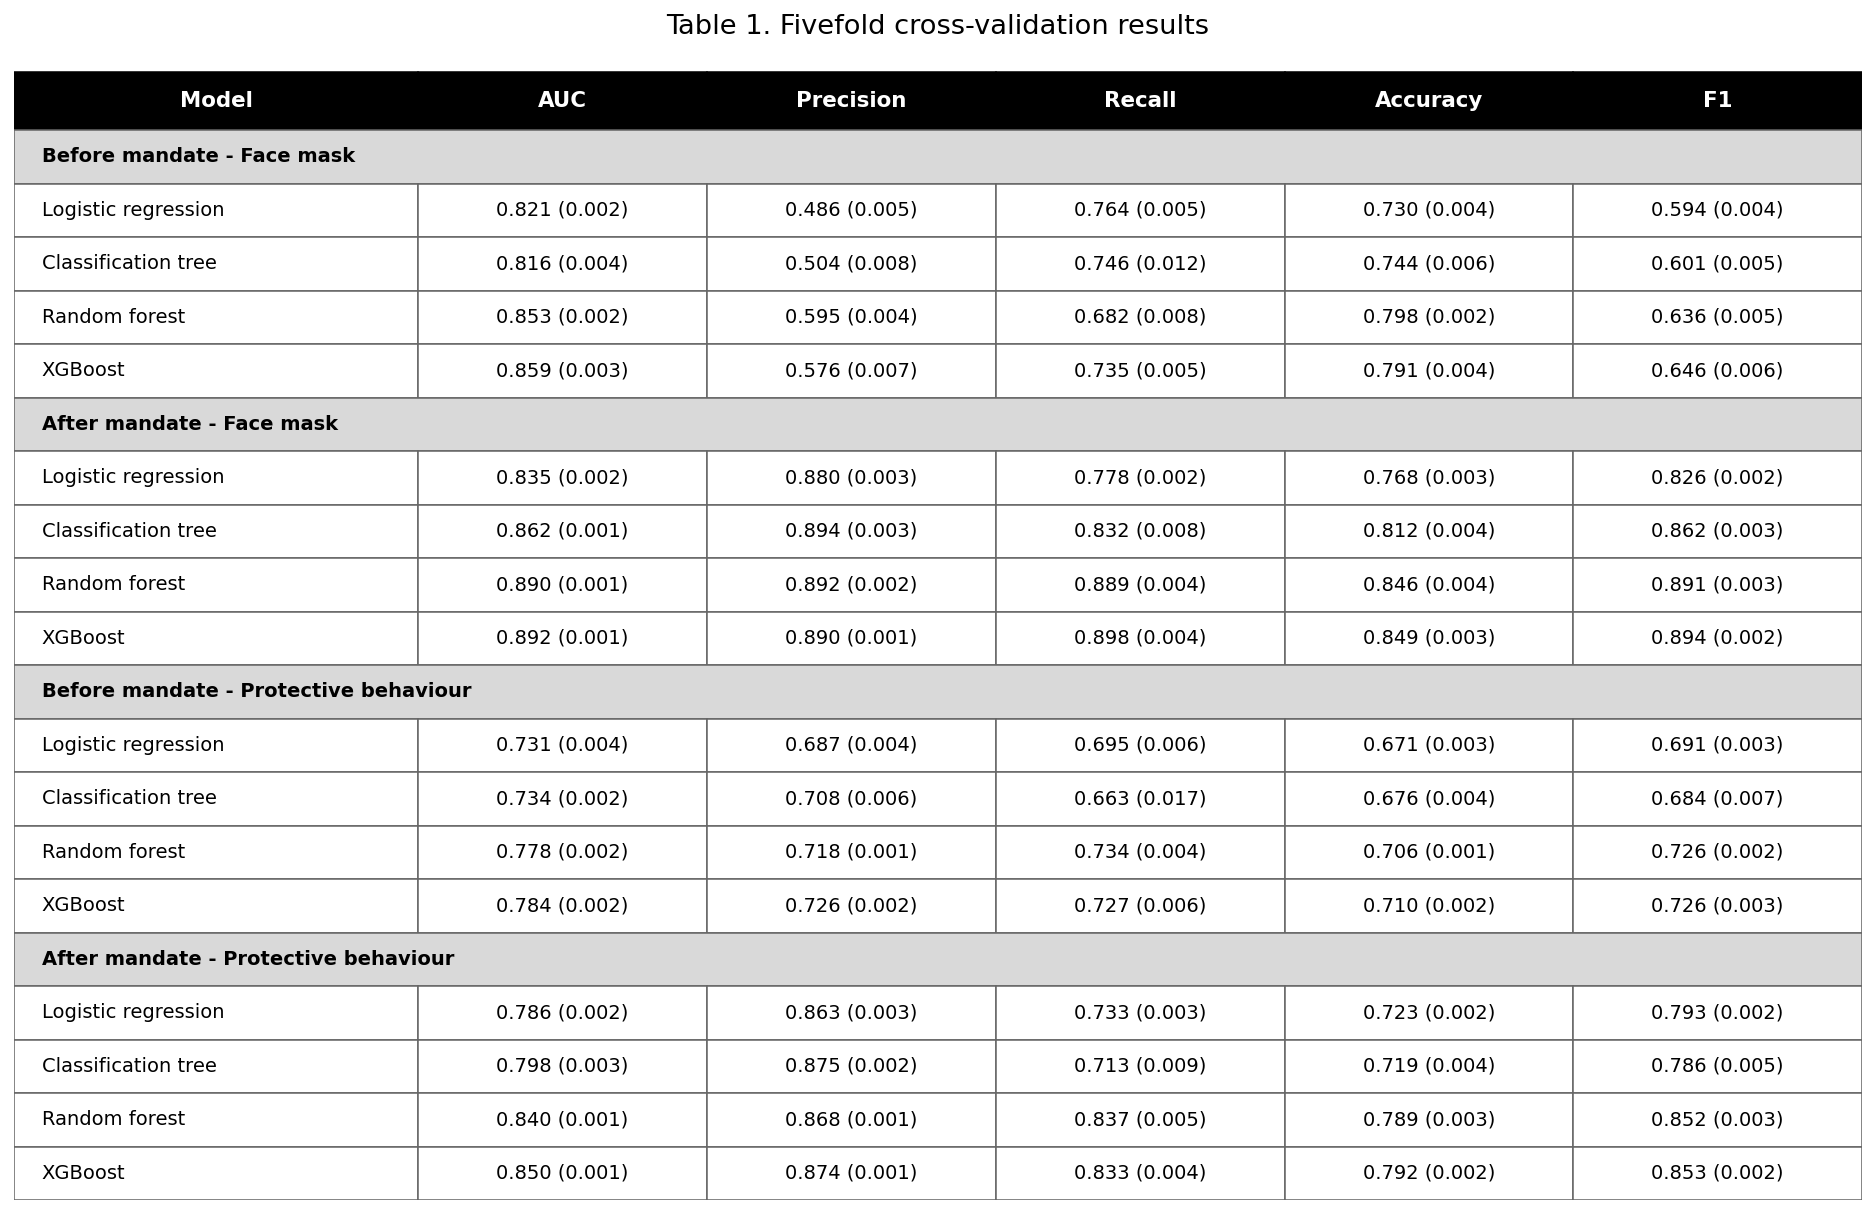

In [56]:
draw_grouped_table(
    df=cv_display,
    title="Table 1. Fivefold cross-validation results",
    out_path=RESULT_DIR / "table_cv_results.png",
    group_col="Task",
    display_cols=["Model", "AUC", "Precision", "Recall", "Accuracy", "F1"],
    figsize=(13.5, 8.8),
    font_size=10,
    header_font_size=11,
    title_font_size=14,
    row_height_data=0.92,
    row_height_group=0.92
)


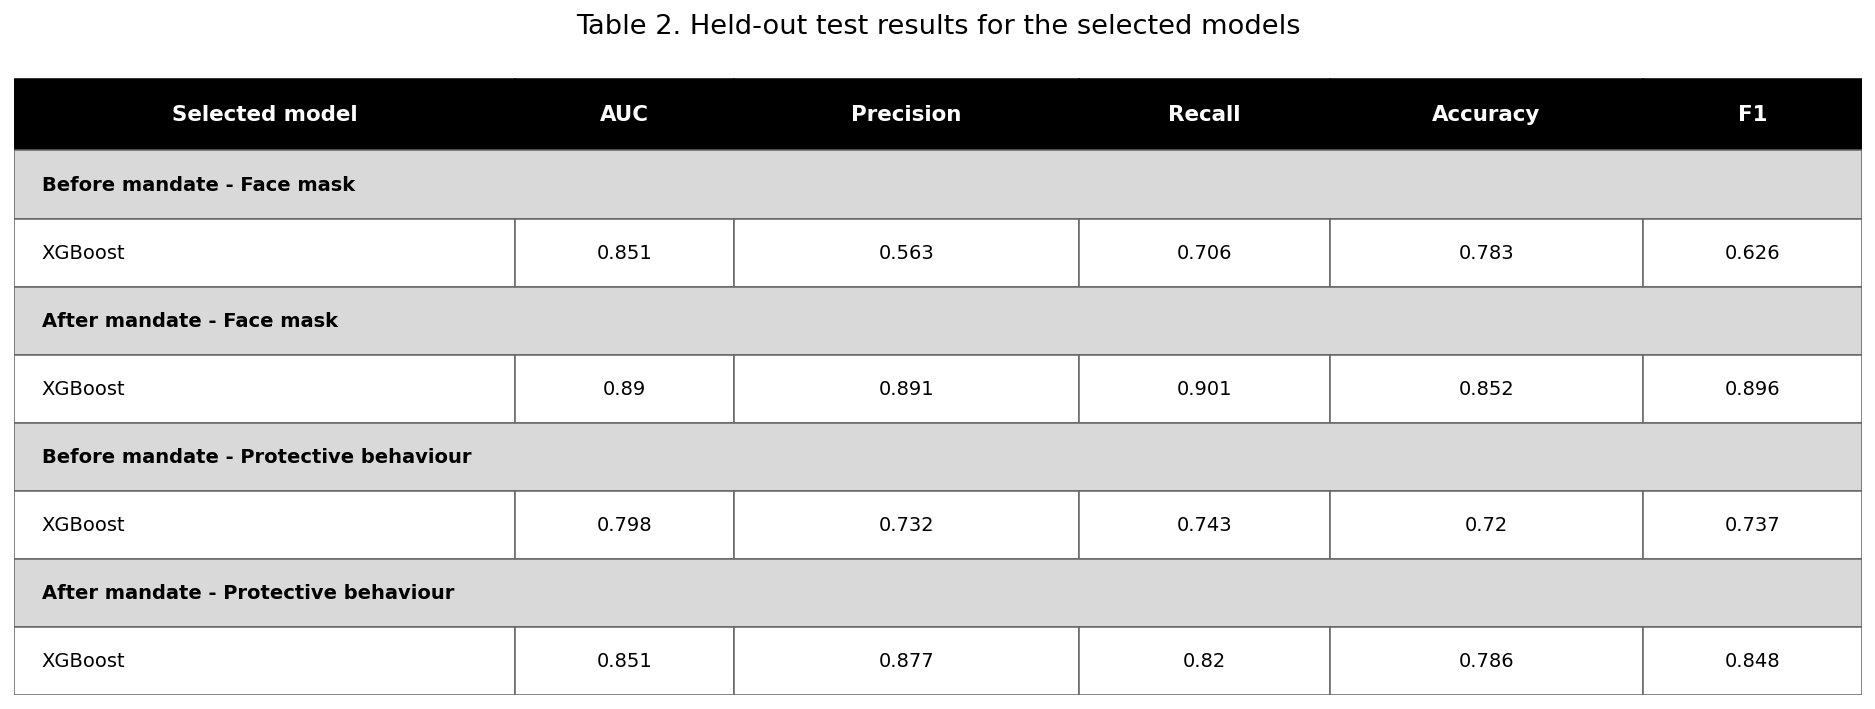

In [55]:
draw_grouped_table(
    df=test_table_selected,
    title="Table 2. Held-out test results for the selected models",
    out_path=RESULT_DIR / "table_test_results.png",
    group_col="Task",
    display_cols=["Selected model", "AUC", "Precision", "Recall", "Accuracy", "F1"],
    figsize=(13.5, 5.2),
    font_size=10,
    header_font_size=11,
    title_font_size=14,
    row_height_data=0.95,
    row_height_group=0.95
)


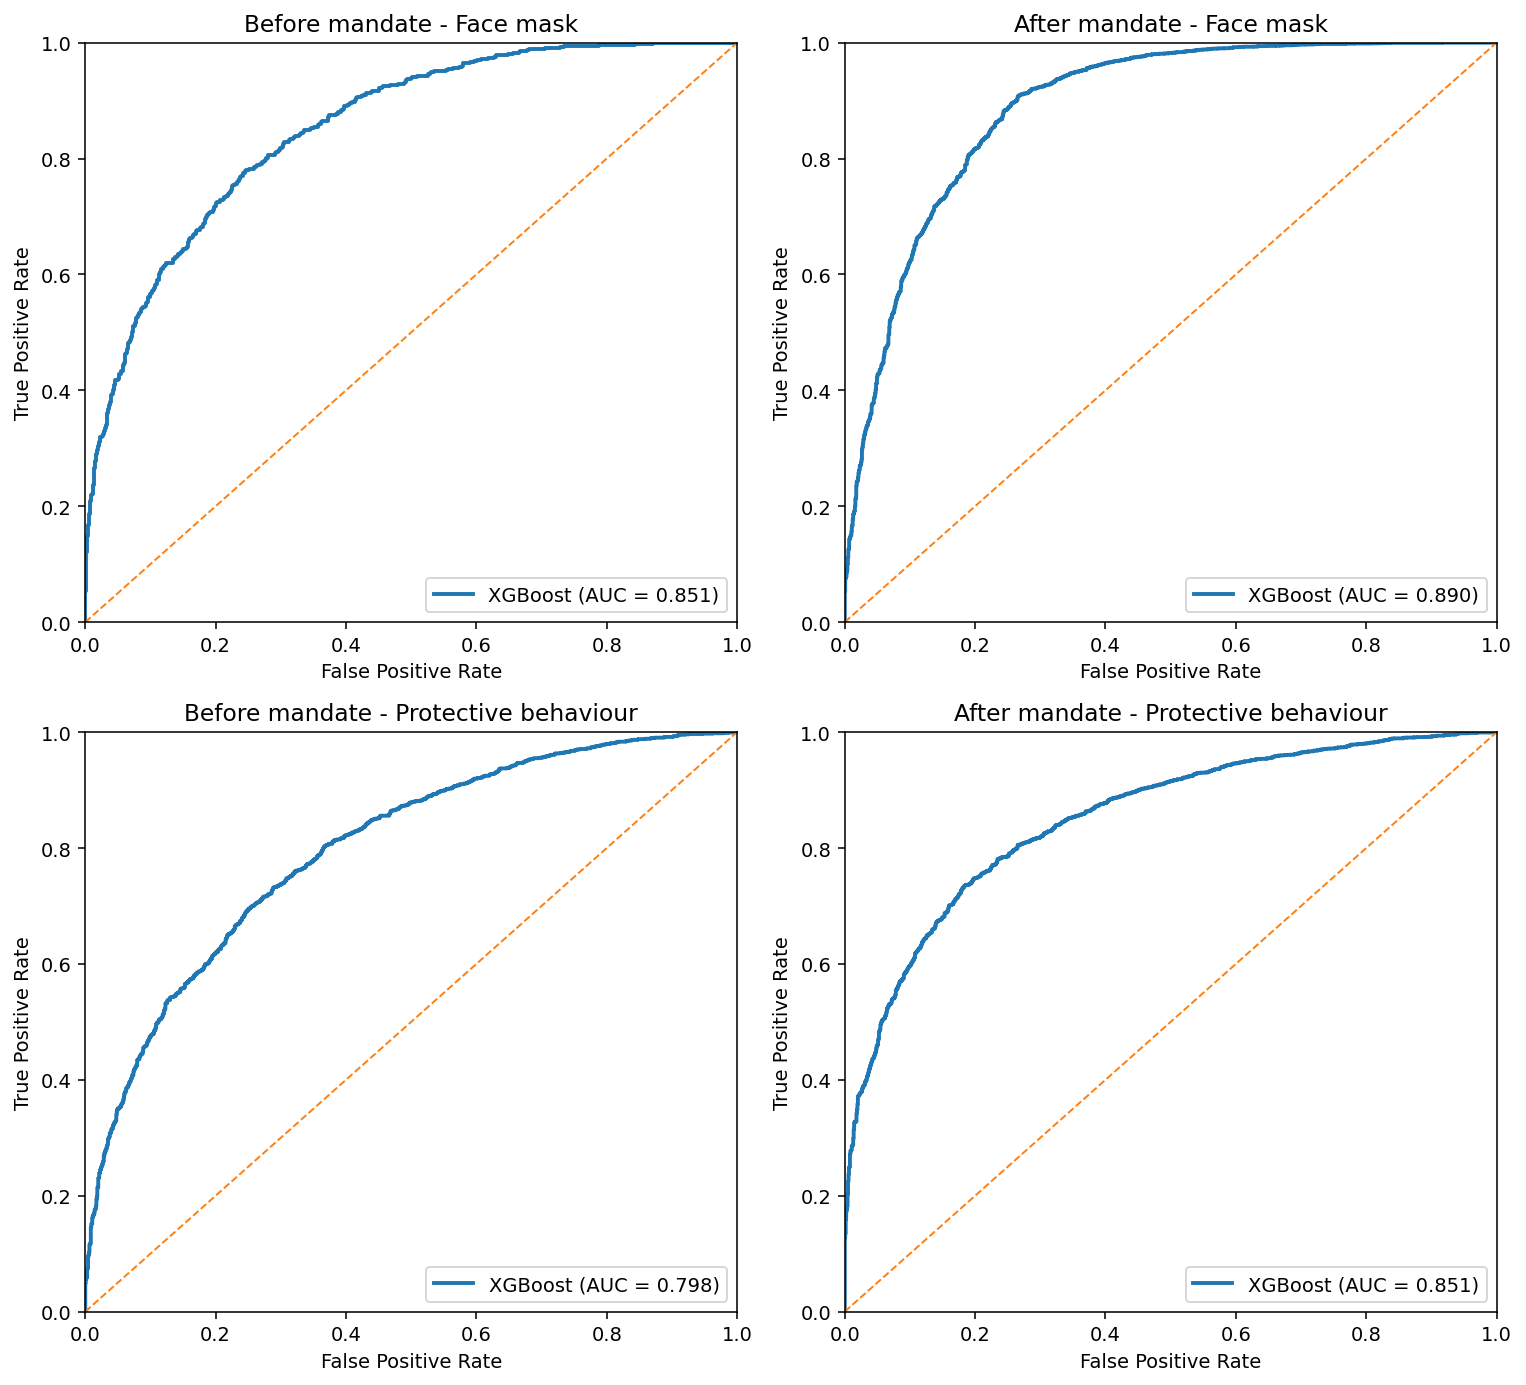

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes = axes.flatten()

for ax, task in zip(axes, TASK_ORDER):
    selected_model_name = selected_model_df.loc[selected_model_df["task"] == task, "selected_model_key"].iloc[0]
    selected_res = all_results[task]["models"][selected_model_name]

    y_true = selected_res["y_test"]
    y_prob = selected_res["y_test_prob"]

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)

    ax.plot(fpr, tpr, linewidth=2, label=f"{MODEL_LABELS[selected_model_name]} (AUC = {auc_val:.3f})")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    ax.set_title(TASKS[task])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULT_DIR / "roc_selected_models.png", bbox_inches="tight", dpi=300)
plt.show()


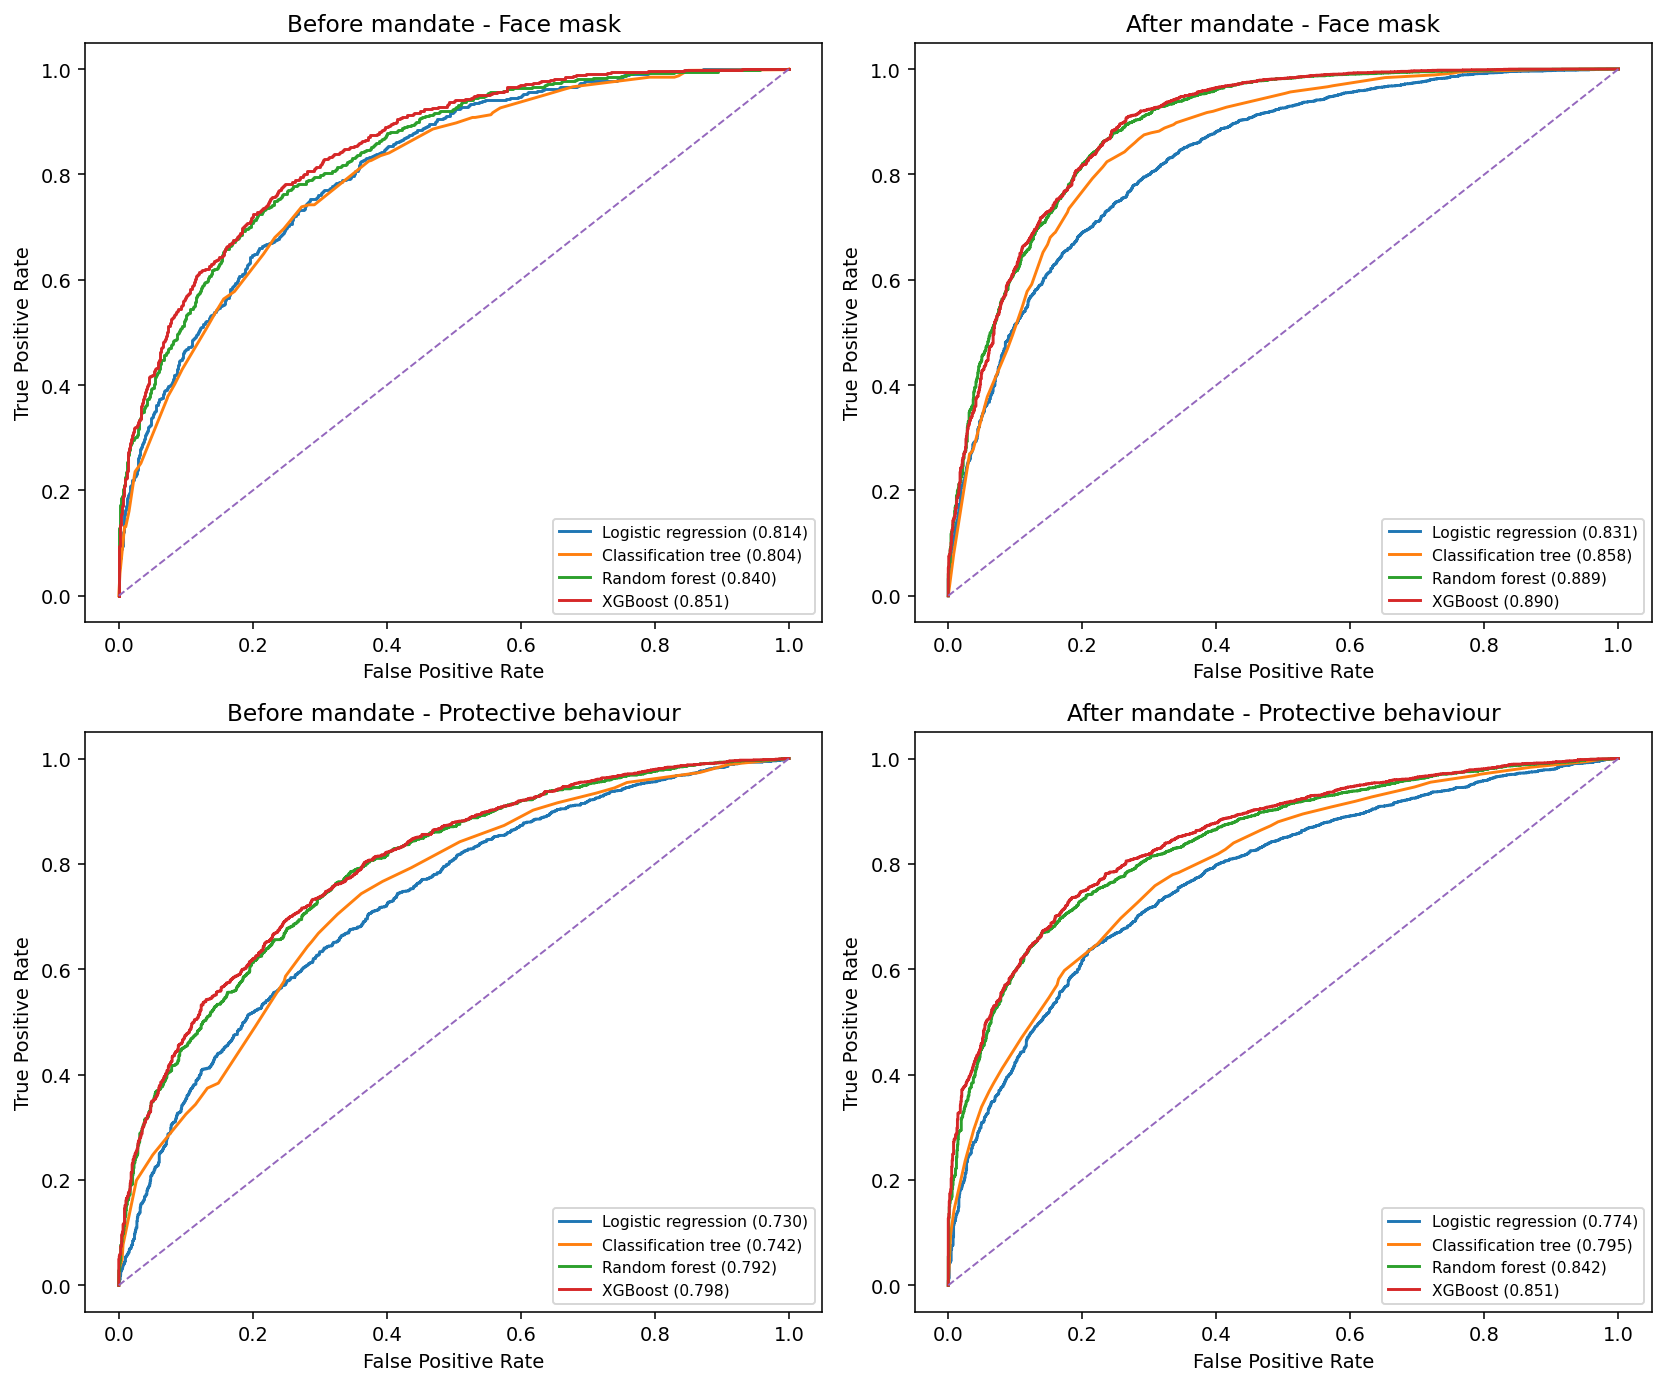

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, task in zip(axes, TASK_ORDER):
    for model_name in MODEL_ORDER:
        res = all_results[task]["models"][model_name]
        y_true = res["y_test"]
        y_prob = res["y_test_prob"]

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val = roc_auc_score(y_true, y_prob)
        ax.plot(fpr, tpr, label=f"{MODEL_LABELS[model_name]} ({auc_val:.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(TASKS[task])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig(RESULT_DIR / "roc_all_models_comparison.png", bbox_inches="tight", dpi=300)
plt.show()


In [37]:
def prepare_pair_importance(task_before, task_after, top_n=10):
    before_model_name = selected_model_df.loc[selected_model_df["task"] == task_before, "selected_model_key"].iloc[0]
    after_model_name = selected_model_df.loc[selected_model_df["task"] == task_after, "selected_model_key"].iloc[0]

    before_df = all_results[task_before]["models"][before_model_name]["feature_df"].copy()
    after_df = all_results[task_after]["models"][after_model_name]["feature_df"].copy()

    before_df["category"] = before_df["feature"].apply(feature_category)
    after_df["category"] = after_df["feature"].apply(feature_category)

    before_top = before_df.head(top_n).copy()
    after_top = after_df.head(top_n).copy()

    feature_union = list(dict.fromkeys(before_top["feature"].tolist() + after_top["feature"].tolist()))

    plot_df = pd.DataFrame({"feature": feature_union})

    plot_df = plot_df.merge(
        before_df[["feature", "importance", "category"]].rename(columns={
            "importance": "before_importance",
            "category": "before_category"
        }),
        on="feature",
        how="left"
    )

    plot_df = plot_df.merge(
        after_df[["feature", "importance", "category"]].rename(columns={
            "importance": "after_importance",
            "category": "after_category"
        }),
        on="feature",
        how="left"
    )

    plot_df["before_importance"] = plot_df["before_importance"].fillna(0)
    plot_df["after_importance"] = plot_df["after_importance"].fillna(0)
    plot_df["category"] = plot_df["before_category"].fillna(plot_df["after_category"]).fillna("Other")
    plot_df["max_importance"] = plot_df[["before_importance", "after_importance"]].max(axis=1)

    plot_df = plot_df.sort_values("max_importance", ascending=True).reset_index(drop=True)

    return plot_df, before_model_name, after_model_name


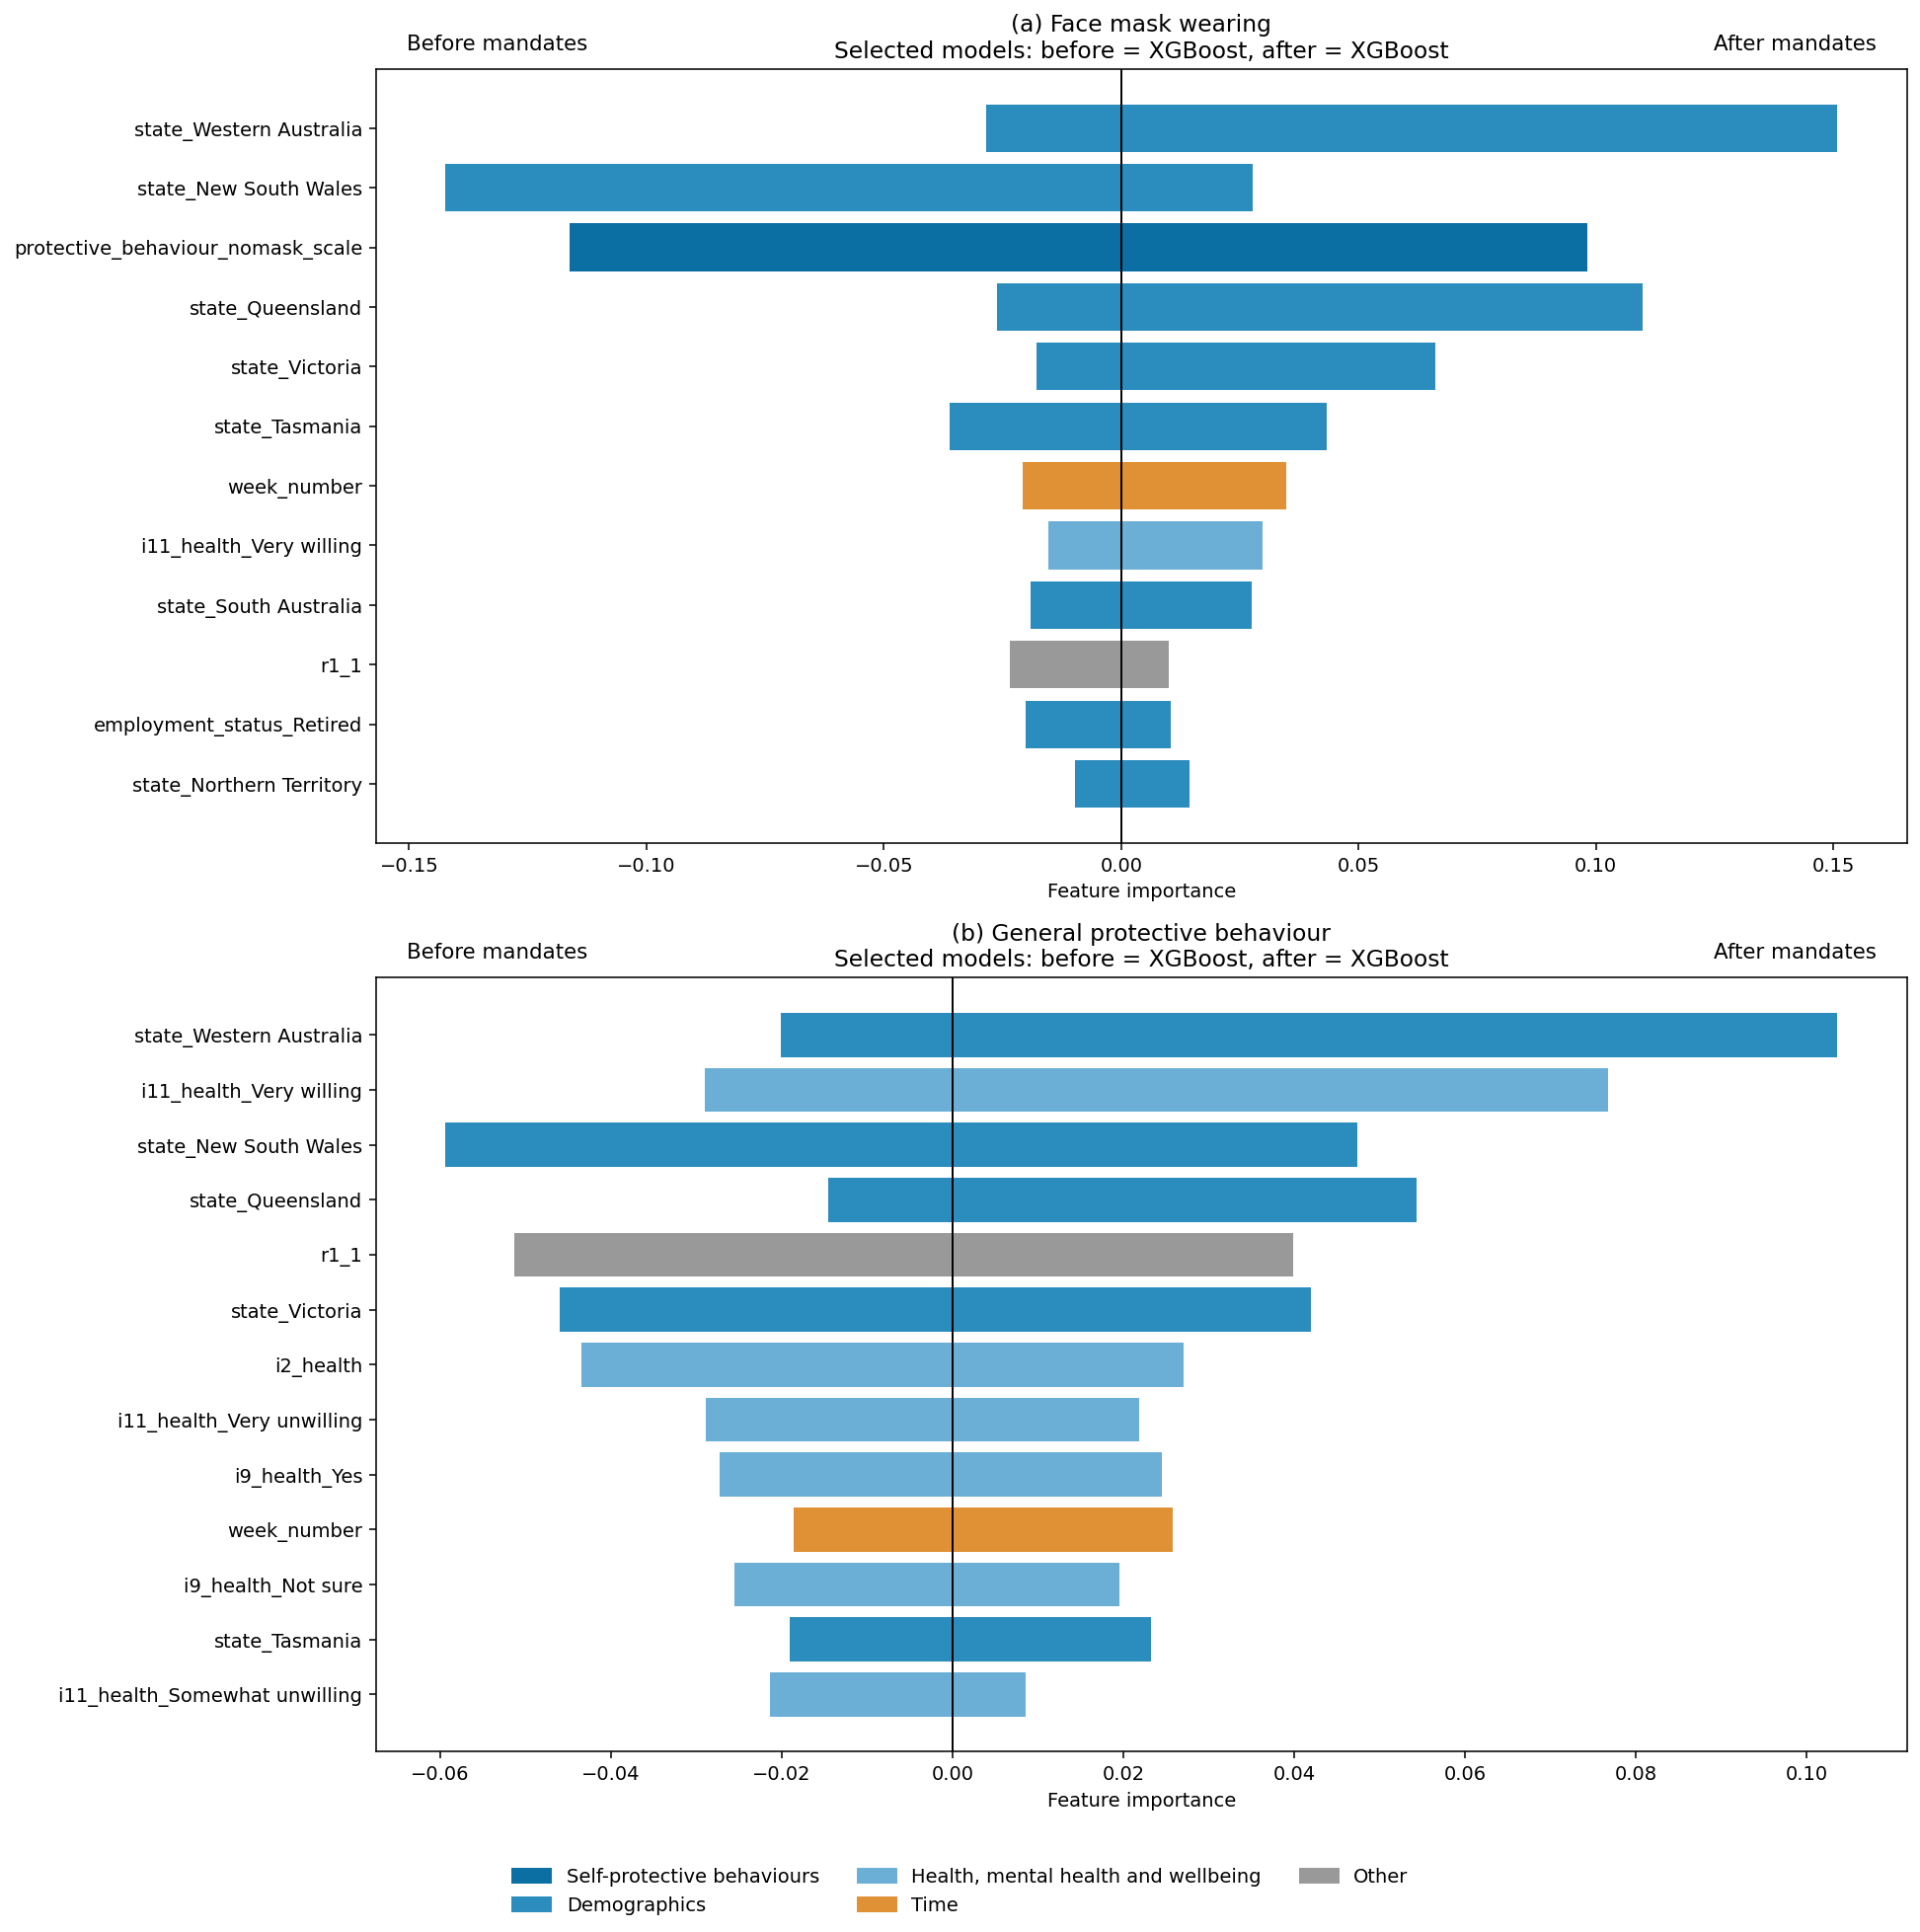

In [38]:
def plot_before_after_importance(ax, plot_df, title, before_label="Before mandates", after_label="After mandates"):
    y = np.arange(len(plot_df))
    before_vals = -plot_df["before_importance"].values
    after_vals = plot_df["after_importance"].values
    colors = [CATEGORY_COLORS.get(c, "#999999") for c in plot_df["category"]]

    ax.barh(y, before_vals, color=colors)
    ax.barh(y, after_vals, color=colors)

    ax.axvline(0, color="black", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["feature"])
    ax.set_xlabel("Feature importance")
    ax.set_title(title)

    ax.text(0.02, 1.02, before_label, transform=ax.transAxes, ha="left", va="bottom", fontsize=11)
    ax.text(0.98, 1.02, after_label, transform=ax.transAxes, ha="right", va="bottom", fontsize=11)


mask_plot_df, mask_before_model, mask_after_model = prepare_pair_importance(
    "before_mask", "after_mask", top_n=10
)
prot_plot_df, prot_before_model, prot_after_model = prepare_pair_importance(
    "before_protective", "after_protective", top_n=10
)

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

plot_before_after_importance(
    axes[0],
    mask_plot_df,
    title=f"(a) Face mask wearing\nSelected models: before = {MODEL_LABELS[mask_before_model]}, after = {MODEL_LABELS[mask_after_model]}"
)

plot_before_after_importance(
    axes[1],
    prot_plot_df,
    title=f"(b) General protective behaviour\nSelected models: before = {MODEL_LABELS[prot_before_model]}, after = {MODEL_LABELS[prot_after_model]}"
)

handles = []
labels = []
for cat in CATEGORY_ORDER:
    if cat in mask_plot_df["category"].values or cat in prot_plot_df["category"].values:
        handles.append(plt.Rectangle((0, 0), 1, 1, color=CATEGORY_COLORS[cat]))
        labels.append(cat)

fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(RESULT_DIR / "feature_importance_selected_models.png", bbox_inches="tight", dpi=300)
plt.show()


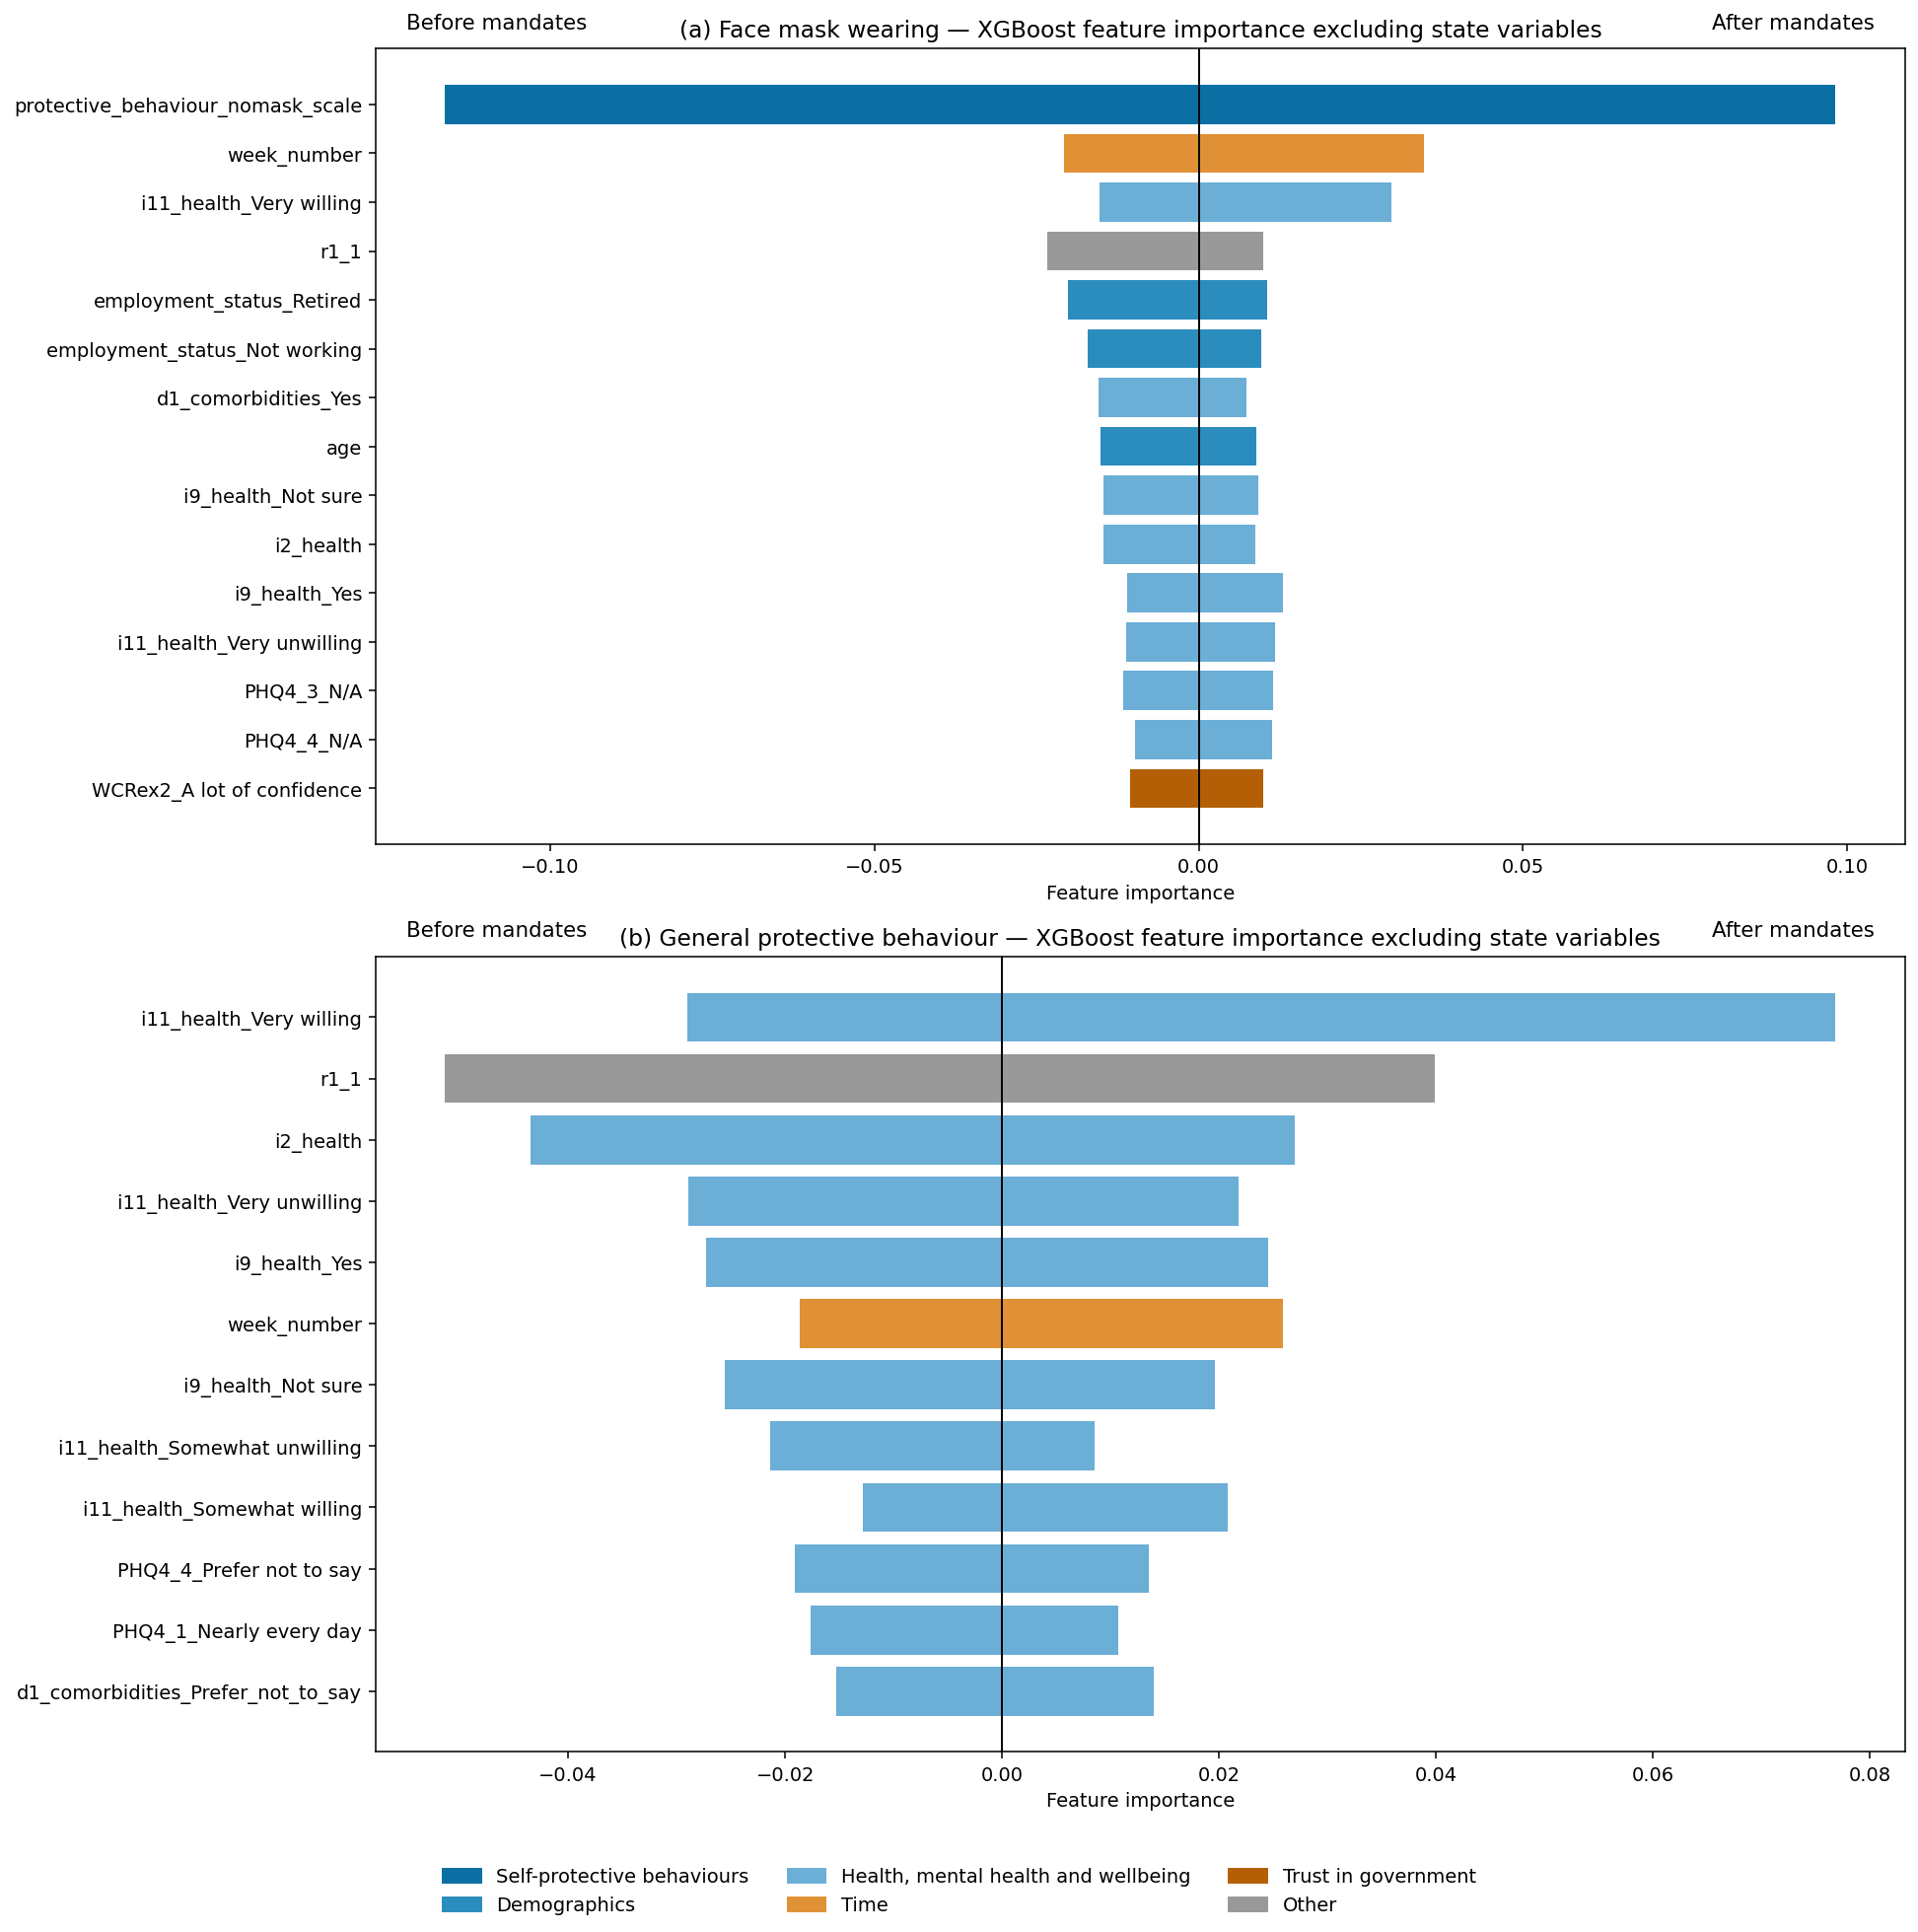

In [39]:
def prepare_fixed_model_pair_no_state(task_before, task_after, model_name="xgboost", top_n=10):
    before_df = all_results[task_before]["models"][model_name]["feature_df"].copy()
    after_df = all_results[task_after]["models"][model_name]["feature_df"].copy()

    # remove all state-related variables
    before_df = before_df[~before_df["feature"].str.startswith("state_")].copy()
    after_df = after_df[~after_df["feature"].str.startswith("state_")].copy()

    before_df["category"] = before_df["feature"].apply(feature_category)
    after_df["category"] = after_df["feature"].apply(feature_category)

    before_top = before_df.head(top_n).copy()
    after_top = after_df.head(top_n).copy()

    feature_union = list(dict.fromkeys(before_top["feature"].tolist() + after_top["feature"].tolist()))

    plot_df = pd.DataFrame({"feature": feature_union})

    plot_df = plot_df.merge(
        before_df[["feature", "importance", "category"]].rename(columns={
            "importance": "before_importance",
            "category": "before_category"
        }),
        on="feature",
        how="left"
    )

    plot_df = plot_df.merge(
        after_df[["feature", "importance", "category"]].rename(columns={
            "importance": "after_importance",
            "category": "after_category"
        }),
        on="feature",
        how="left"
    )

    plot_df["before_importance"] = plot_df["before_importance"].fillna(0)
    plot_df["after_importance"] = plot_df["after_importance"].fillna(0)
    plot_df["category"] = plot_df["before_category"].fillna(plot_df["after_category"]).fillna("Other")
    plot_df["max_importance"] = plot_df[["before_importance", "after_importance"]].max(axis=1)

    return plot_df.sort_values("max_importance", ascending=True).reset_index(drop=True)


mask_xgb_nostate_df = prepare_fixed_model_pair_no_state(
    "before_mask",
    "after_mask",
    model_name="xgboost",
    top_n=10
)

prot_xgb_nostate_df = prepare_fixed_model_pair_no_state(
    "before_protective",
    "after_protective",
    model_name="xgboost",
    top_n=10
)

fig, axes = plt.subplots(2, 1, figsize=(14, 14))

plot_before_after_importance(
    axes[0],
    mask_xgb_nostate_df,
    title="(a) Face mask wearing — XGBoost feature importance excluding state variables"
)

plot_before_after_importance(
    axes[1],
    prot_xgb_nostate_df,
    title="(b) General protective behaviour — XGBoost feature importance excluding state variables"
)

handles = []
labels = []
for cat in CATEGORY_ORDER:
    if cat in mask_xgb_nostate_df["category"].values or cat in prot_xgb_nostate_df["category"].values:
        handles.append(plt.Rectangle((0, 0), 1, 1, color=CATEGORY_COLORS[cat]))
        labels.append(cat)

fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(RESULT_DIR / "feature_importance_xgboost_nostate.png", bbox_inches="tight", dpi=300)
plt.show()


In [40]:
display(Markdown("## Files created in Result/"))
for p in sorted(RESULT_DIR.iterdir()):
    print(p.name)


## Files created in Result/

auc_pivot.csv
f1_pivot.csv
feature_importance_selected_models.png
feature_importance_xgboost_nostate.png
roc_all_models_comparison.png
roc_selected_models.png
selected_model_summary.csv
table_cv_results.csv
table_cv_results.png
table_cv_results_full.csv
table_test_results.csv
table_test_results.png
